In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def show(img, title="", cmap="gray", size=6):
    plt.figure(figsize=(size, size))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

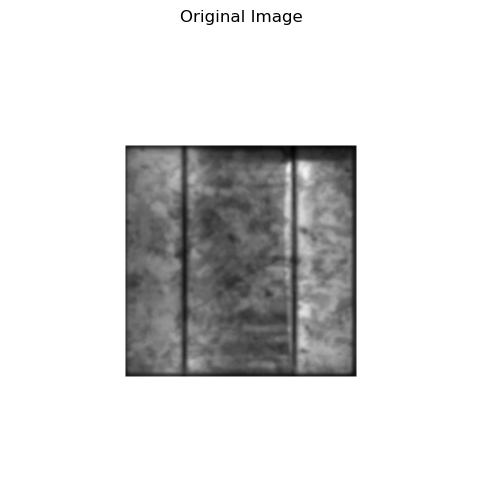

In [121]:
img = cv2.imread(r"D:\PROGRAMMING\Internships_assignments\ResearchInternIITMandi\dataset\dataset\BMRK_00106_cell0286.png", cv2.IMREAD_GRAYSCALE)
show(img, "Original Image")

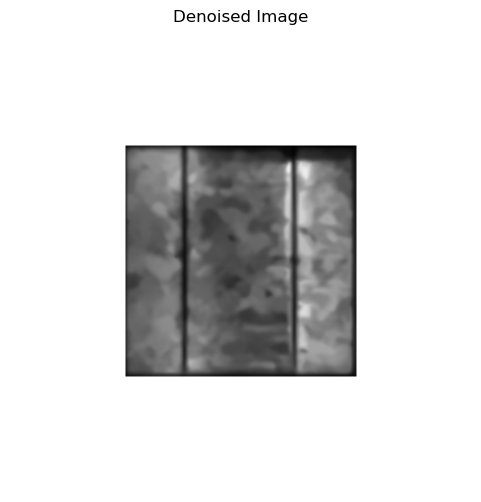

In [122]:
denoised = cv2.fastNlMeansDenoising(img, h=10)
show(denoised, "Denoised Image")

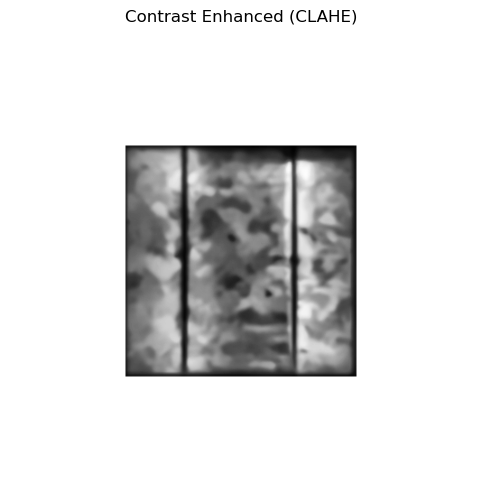

In [123]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(denoised)
show(enhanced, "Contrast Enhanced (CLAHE)")

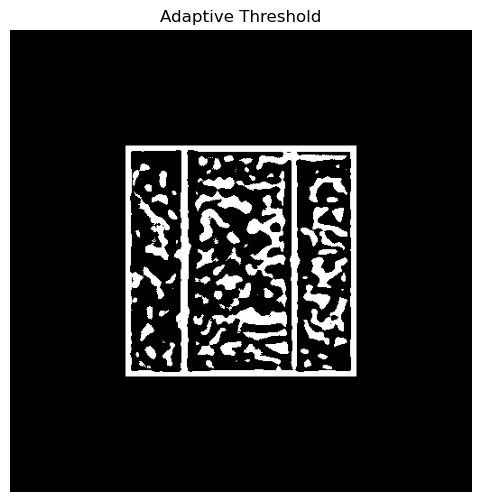

In [124]:
th = cv2.adaptiveThreshold(enhanced, 255,
                           cv2.ADAPTIVE_THRESH_MEAN_C,
                           cv2.THRESH_BINARY_INV,
                           15, 5)
show(th, "Adaptive Threshold")

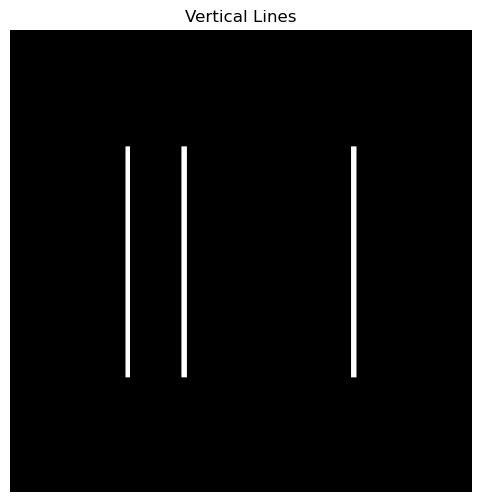

In [125]:
kernel_vert = cv2.getStructuringElement(cv2.MORPH_RECT, (3, img.shape[0]//2))
vert_lines = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel_vert)
show(vert_lines, "Vertical Lines")

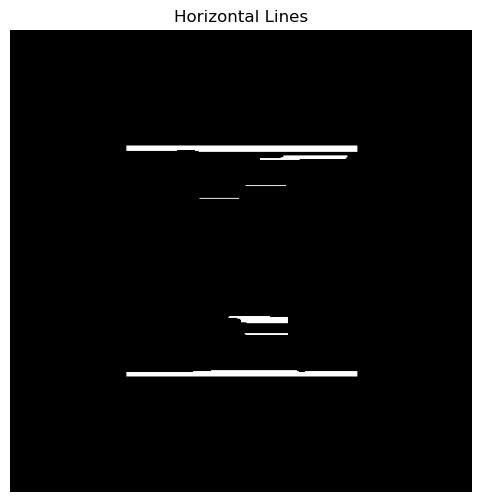

In [126]:
kernel_horz = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
horz_lines = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel_horz)
show(horz_lines, "Horizontal Lines")

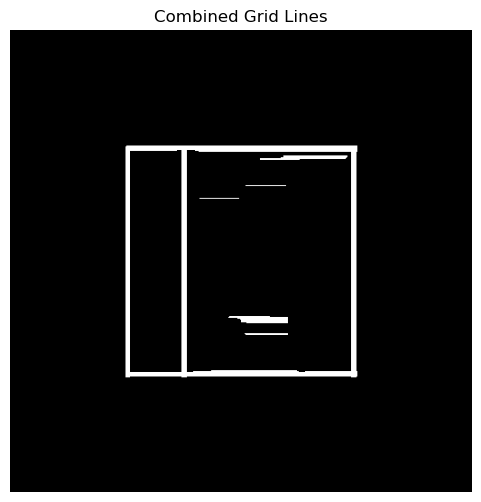

In [127]:
grid = cv2.addWeighted(vert_lines, 1, horz_lines, 1, 0)
show(grid, "Combined Grid Lines")

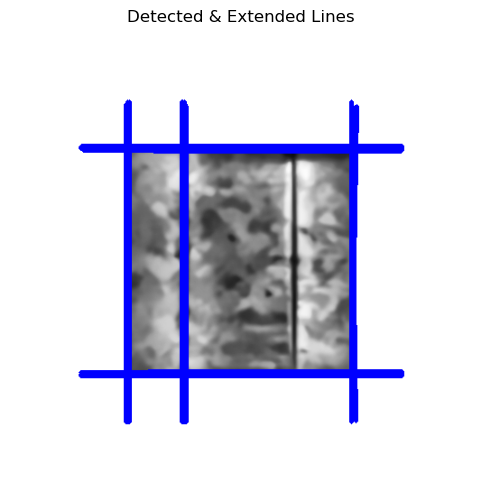

In [128]:
lines = cv2.HoughLinesP(
    grid,
    rho=1,
    theta=np.pi / 180,
    threshold=100,
    minLineLength=img.shape[1] // 4,
    maxLineGap=20
)

line_img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

h, w = line_img.shape[:2]
extend_len = 50  # number of pixels to extend each end

for line in lines:
    x1, y1, x2, y2 = line[0]

    # Direction vector
    dx = x2 - x1
    dy = y2 - y1

    # Normalize
    length = np.sqrt(dx * dx + dy * dy)
    if length == 0:
        continue

    ux = dx / length
    uy = dy / length

    # Extend both ends
    x1_ext = int(x1 - ux * extend_len)
    y1_ext = int(y1 - uy * extend_len)
    x2_ext = int(x2 + ux * extend_len)
    y2_ext = int(y2 + uy * extend_len)

    # Clip to image boundaries
    x1_ext = np.clip(x1_ext, 0, w - 1)
    y1_ext = np.clip(y1_ext, 0, h - 1)
    x2_ext = np.clip(x2_ext, 0, w - 1)
    y2_ext = np.clip(y2_ext, 0, h - 1)

    cv2.line(
        line_img,
        (x1_ext, y1_ext),
        (x2_ext, y2_ext),
        (0, 0, 255),
        3
    )

show(line_img, "Detected & Extended Lines")


In [129]:
vertical_lines = []
horizontal_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]
    if x2 - x1 == 0:
        slope = float('inf')
    else:
        slope = (y2 - y1) / (x2 - x1)

    if abs(slope) > 5:  # Near vertical
        vertical_lines.append(line[0])
    elif abs(slope) < 0.2:  # Near horizontal
        horizontal_lines.append(line[0])

print(f"Vertical lines detected: {len(vertical_lines)}")
print(f"Horizontal lines detected: {len(horizontal_lines)}")


Vertical lines detected: 16
Horizontal lines detected: 13


In [130]:
from sklearn.cluster import DBSCAN

Merged vertical lines: 3
Merged horizontal lines: 2


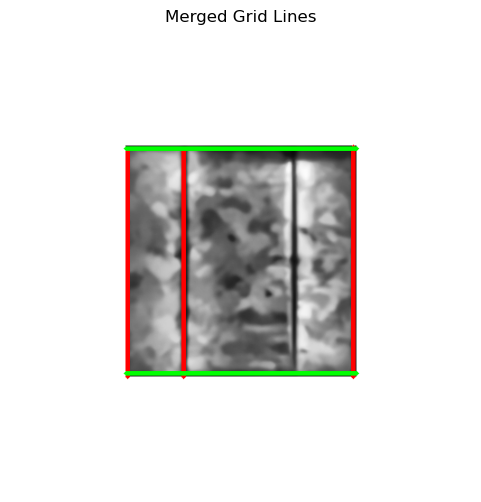

In [131]:
# -----------------------------
# Helper functions
# -----------------------------
def merge_vertical_lines(lines, eps=10):
    # Use x-coordinate only for clustering
    xs = np.array([[ (l[0] + l[2]) / 2 ] for l in lines])

    db = DBSCAN(eps=eps, min_samples=1).fit(xs)
    labels = db.labels_

    merged = []
    for lbl in np.unique(labels):
        cluster = [lines[i] for i in range(len(lines)) if labels[i] == lbl]

        x = int(np.mean([ (l[0] + l[2]) / 2 for l in cluster]))
        y1 = int(min(l[1] for l in cluster))
        y2 = int(max(l[3] for l in cluster))

        merged.append([x, y1, x, y2])

    return merged


def merge_horizontal_lines(lines, eps=10):
    # Use y-coordinate only for clustering
    ys = np.array([[ (l[1] + l[3]) / 2 ] for l in lines])

    db = DBSCAN(eps=eps, min_samples=1).fit(ys)
    labels = db.labels_

    merged = []
    for lbl in np.unique(labels):
        cluster = [lines[i] for i in range(len(lines)) if labels[i] == lbl]

        y = int(np.mean([ (l[1] + l[3]) / 2 for l in cluster]))
        x1 = int(min(l[0] for l in cluster))
        x2 = int(max(l[2] for l in cluster))

        merged.append([x1, y, x2, y])

    return merged


# -----------------------------
# Merge close lines
# -----------------------------
merged_vertical_lines = merge_vertical_lines(vertical_lines, eps=12)
merged_horizontal_lines = merge_horizontal_lines(horizontal_lines, eps=12)

print(f"Merged vertical lines: {len(merged_vertical_lines)}")
print(f"Merged horizontal lines: {len(merged_horizontal_lines)}")


# -----------------------------
# Visualization
# -----------------------------
vis = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

for x1, y1, x2, y2 in merged_vertical_lines:
    cv2.line(vis, (x1, y1), (x2, y2), (255, 0, 0), 3)

for x1, y1, x2, y2 in merged_horizontal_lines:
    cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 3)

show(vis, "Merged Grid Lines")


In [132]:
# -----------------------------
# Generate all candidate boxes (robust)
# -----------------------------
v_lines = sorted(extended_vertical_lines, key=lambda l: l[0])
h_lines = sorted(extended_horizontal_lines, key=lambda l: l[1])

candidates = []

MIN_AREA_RATIO = 0.20
IMG_AREA = W * H

ASPECT_TOL = 0.35     # allow non-perfect squares
LINE_PROX = 15        # allow close parallel lines

for i in range(len(v_lines)):
    for j in range(i + 1, len(v_lines)):
        x_left  = v_lines[i][0]
        x_right = v_lines[j][0]

        if abs(x_right - x_left) < LINE_PROX:
            continue

        for k in range(len(h_lines)):
            for l in range(k + 1, len(h_lines)):
                y_top = h_lines[k][1]
                y_bot = h_lines[l][1]

                if abs(y_bot - y_top) < LINE_PROX:
                    continue

                # Clamp
                x_left_c  = max(0, x_left)
                x_right_c = min(W, x_right)
                y_top_c   = max(0, y_top)
                y_bot_c   = min(H, y_bot)

                w = x_right_c - x_left_c
                h = y_bot_c - y_top_c

                if w <= 0 or h <= 0:
                    continue

                area = w * h
                if area < MIN_AREA_RATIO * IMG_AREA:
                    continue

                aspect = w / h
                aspect_dist = abs(np.log(aspect))

                if aspect_dist > ASPECT_TOL:
                    continue

                # Corner robustness score (clipped corners tolerant)
                rectangularity = area / (w * h)

                score = (
                    aspect_dist * 0.7
                    + (1 - rectangularity) * 0.3
                )

                candidates.append({
                    "box": (x_left_c, y_top_c, x_right_c, y_bot_c),
                    "score": score,
                    "area": area
                })

# -----------------------------
# Select best candidate
# -----------------------------
assert len(candidates) > 0, "No valid cell found"

candidates = sorted(
    candidates,
    key=lambda c: (c["score"], -c["area"])
)

best = candidates[0]
x_left, y_top, x_right, y_bot = best["box"]

# -----------------------------
# Extract solar cell
# -----------------------------
cell = img[y_top:y_bot, x_left:x_right]
show(cell, "Extracted Solar Cell (Corner-Robust)")

# -----------------------------
# Visualization
# -----------------------------
vis = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
cv2.rectangle(vis, (x_left, y_top), (x_right, y_bot), (0, 0, 255), 3)
show(vis, "Final Cell Bounding Box")


NameError: name 'extended_vertical_lines' is not defined

In [133]:
# Intersection points (clockwise)
tl = (x_left, y_top)
tr = (x_right, y_top)
br = (x_right, y_bot)
bl = (x_left, y_bot)

pts_src = np.array([tl, tr, br, bl], dtype=np.float32)


NameError: name 'x_left' is not defined

In [134]:
def is_perspective_needed(pts, tol=5):
    # Compare opposite edges
    w1 = np.linalg.norm(pts[0] - pts[1])
    w2 = np.linalg.norm(pts[3] - pts[2])
    h1 = np.linalg.norm(pts[0] - pts[3])
    h2 = np.linalg.norm(pts[1] - pts[2])

    return abs(w1 - w2) > tol or abs(h1 - h2) > tol

need_perspective = is_perspective_needed(pts_src)
print("Perspective correction needed:", need_perspective)


NameError: name 'pts_src' is not defined

In [82]:
if need_perspective:
    width = int(max(
        np.linalg.norm(tr - tl),
        np.linalg.norm(br - bl)
    ))

    height = int(max(
        np.linalg.norm(bl - tl),
        np.linalg.norm(br - tr)
    ))

    pts_dst = np.array([
        [0, 0],
        [width - 1, 0],
        [width - 1, height - 1],
        [0, height - 1]
    ], dtype=np.float32)

    M = cv2.getPerspectiveTransform(pts_src, pts_dst)
    cell_corrected = cv2.warpPerspective(img, M, (width, height))

else:
    cell_corrected = cell.copy()


NameError: name 'need_perspective' is not defined

In [45]:
show(cell_corrected, "Perspective Corrected Solar Cell")

NameError: name 'cell_corrected' is not defined